In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

import xgboost as xgb
import lightgbm as lgb

print("xgb:", xgb.__version__)
print("lgb:", lgb.__version__)

xgb: 3.4.1
lgb: 4.7.0


In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.")
common_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df["Title"].where(df["Title"].isin(common_titles), "Rare")

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df = df[["Survived", "Pclass", "Sex", "Age", "Fare",
         "Embarked", "Title", "FamilySize", "IsAlone"]]

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df, columns=["Sex", "Embarked", "Title"], drop_first=False)

X = df.drop(columns=["Survived"])
y = df["Survived"]

print("X:", X.shape, "y:", y.shape)

X: (891, 15) y: (891,)


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
)

scores_xgb = cross_val_score(xgb_model, X, y, cv=cv, scoring="accuracy")
print(f"XGBoost: mean={scores_xgb.mean():.4f}, std={scores_xgb.std():.4f}")

XGBoost: mean=0.8440, std=0.0188


In [10]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
)

scores_lgb = cross_val_score(lgb_model, X, y, cv=cv, scoring="accuracy")
print(f"LightGBM: mean={scores_lgb.mean():.4f}, std={scores_lgb.std():.4f}")

LightGBM: mean=0.8440, std=0.0165


In [12]:
X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost на test ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

=== XGBoost на test ===
Accuracy:  0.8156
Precision: 0.8000
Recall:    0.6957
F1:        0.7442
ROC-AUC:   0.8329


In [13]:
print(classification_report(y_test, y_pred, target_names=["Погиб", "Выжил"]))

              precision    recall  f1-score   support

       Погиб       0.82      0.89      0.86       110
       Выжил       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



[[98 12]
 [21 48]]


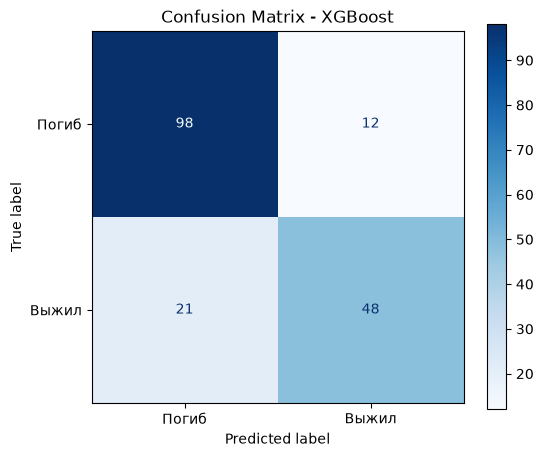

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Погиб", "Выжил"]).plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [19]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Порог':<8} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print('-'*40)
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"{t:<8} {p:<10.4f} {r:<10.4f} {f:<10.4f}")

Порог    Precision  Recall     F1        
----------------------------------------
0.3      0.7037     0.8261     0.7600    
0.4      0.7857     0.7971     0.7914    
0.5      0.8000     0.6957     0.7442    
0.6      0.8036     0.6522     0.7200    
0.7      0.8298     0.5652     0.6724    


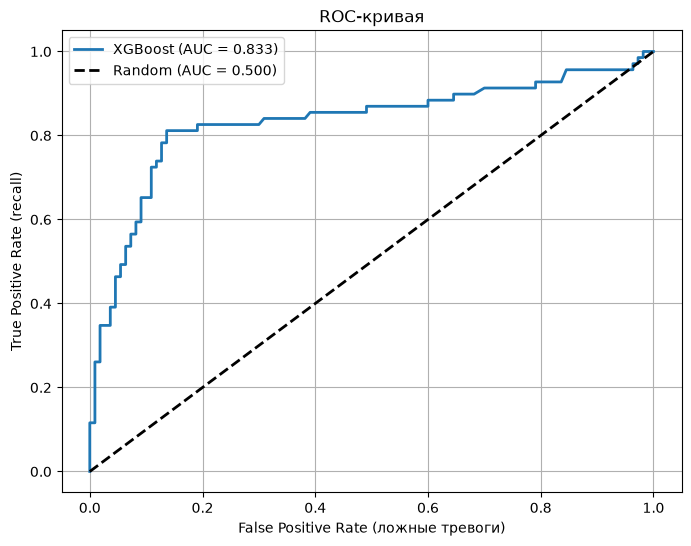

In [20]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0,1], "k--", label="Random (AUC = 0.500)", linewidth=2)
plt.xlabel("False Positive Rate (ложные тревоги)")
plt.ylabel("True Positive Rate (recall)")
plt.title("ROC-кривая")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "Модель": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }

models = {
    "LR":  Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "RF":  RandomForestClassifier(n_estimators=200, max_depth=7, min_samples_leaf=3, random_state=42),
    "GB":  GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
    "XGB": xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0),
    "LGB": lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    results.append(evaluate_model(model, X_train, X_test, y_train, y_test, name))

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))

Модель  Accuracy  Precision  Recall     F1  ROC-AUC
    LR    0.8492     0.8281  0.7681 0.7970   0.8826
    RF    0.8324     0.8421  0.6957 0.7619   0.8549
    GB    0.8268     0.8167  0.7101 0.7597   0.8341
   XGB    0.8156     0.8000  0.6957 0.7442   0.8329
   LGB    0.8156     0.8000  0.6957 0.7442   0.8304


In [22]:
seeds = [0, 1, 42, 100, 123, 7, 21, 88, 55, 999]
results = {name: [] for name in models}

for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        results[name].append(accuracy_score(y_te, model.predict(X_te)))

print(f"{'Модель':<8} {'Mean':<10} {'Std':<10}")
print("-" * 30)
for name, scores in results.items():
    print(f"{name:<8} {np.mean(scores):<10.4f} {np.std(scores):<10.4f}")

Модель   Mean       Std       
------------------------------
LR       0.8341     0.0192    
RF       0.8397     0.0228    
GB       0.8330     0.0231    
XGB      0.8318     0.0210    
LGB      0.8251     0.0263    
